In [6]:
# Core Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Tools
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Models (Base Models for Research)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

# Ensemble (For Novelty)
from sklearn.ensemble import StackingClassifier

# Dataset (Research credible dataset)
from sklearn.datasets import load_breast_cancer

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [7]:
# Load Breast Cancer Dataset (Scientific & Suitable for Research)
data = load_breast_cancer()

# Features and Target
X = data.data
y = data.target

# Convert to DataFrame (for better analysis)
df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y

print("Dataset Loaded Successfully")
print("Shape of Dataset:", df.shape)
df.head()

Dataset Loaded Successfully
Shape of Dataset: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

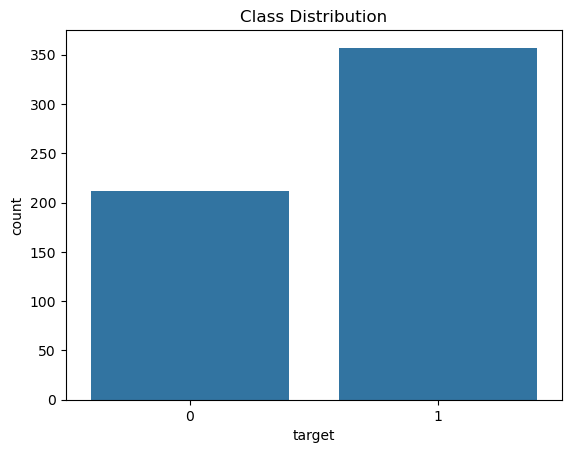

In [8]:
# Basic Information
print(df.info())

# Check Missing Values
print("\nMissing Values:\n", df.isnull().sum())

# Class Distribution (Very Important for Generalization)
sns.countplot(x='target', data=df)
plt.title("Class Distribution")
plt.show()

In [9]:
# Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

Training Set Shape: (455, 30)
Testing Set Shape: (114, 30)


In [10]:
# Standardization (Improves Model Stability & Prediction)
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Feature Scaling Completed")

Feature Scaling Completed


In [11]:
# Base Models for Comparative Generalization Study
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
lr_model = LogisticRegression(max_iter=1000, random_state=42)

print("Base Models Initialized:")
print("1. Random Forest")
print("2. Support Vector Machine")
print("3. Logistic Regression")

Base Models Initialized:
1. Random Forest
2. Support Vector Machine
3. Logistic Regression


In [12]:
# 5-Fold Cross-Validation (Core Experiment)
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validation scores
rf_cv = cross_val_score(rf_model, X_train, y_train, cv=kfold, scoring='accuracy')
svm_cv = cross_val_score(svm_model, X_train, y_train, cv=kfold, scoring='accuracy')
lr_cv = cross_val_score(lr_model, X_train, y_train, cv=kfold, scoring='accuracy')

print("Random Forest CV Accuracy:", rf_cv.mean())
print("SVM CV Accuracy:", svm_cv.mean())
print("Logistic Regression CV Accuracy:", lr_cv.mean())

Random Forest CV Accuracy: 0.956043956043956
SVM CV Accuracy: 0.9736263736263737
Logistic Regression CV Accuracy: 0.9714285714285715


In [13]:
# Train Random Forest (example best baseline)
rf_model.fit(X_train, y_train)

# Predictions
train_pred = rf_model.predict(X_train)
test_pred = rf_model.predict(X_test)

# Accuracy Calculation
train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)

# Generalization Gap (Research Novelty)
generalization_gap = abs(train_accuracy - test_accuracy)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)
print("Generalization Gap:", generalization_gap)

Training Accuracy: 1.0
Testing Accuracy: 0.956140350877193
Generalization Gap: 0.04385964912280704


In [14]:
# Stacking Ensemble (Proposed Novel Model)
estimators = [
    ('rf', rf_model),
    ('svm', svm_model),
    ('lr', lr_model)
]

stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression()
)

# Cross-validation for stacked model
stack_cv_scores = cross_val_score(stack_model, X_train, y_train, cv=5)

print("Stacked Model CV Accuracy:", stack_cv_scores.mean())

Stacked Model CV Accuracy: 0.9780219780219781


In [15]:
# Stratified K-Fold Cross Validation (Better for Generalization)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_skf = cross_val_score(rf_model, X_train, y_train, cv=skf, scoring='accuracy')
svm_skf = cross_val_score(svm_model, X_train, y_train, cv=skf, scoring='accuracy')
lr_skf = cross_val_score(lr_model, X_train, y_train, cv=skf, scoring='accuracy')

print("Stratified K-Fold Results:")
print("Random Forest:", rf_skf.mean())
print("SVM:", svm_skf.mean())
print("Logistic Regression:", lr_skf.mean())

Stratified K-Fold Results:
Random Forest: 0.9626373626373628
SVM: 0.9670329670329672
Logistic Regression: 0.9780219780219781


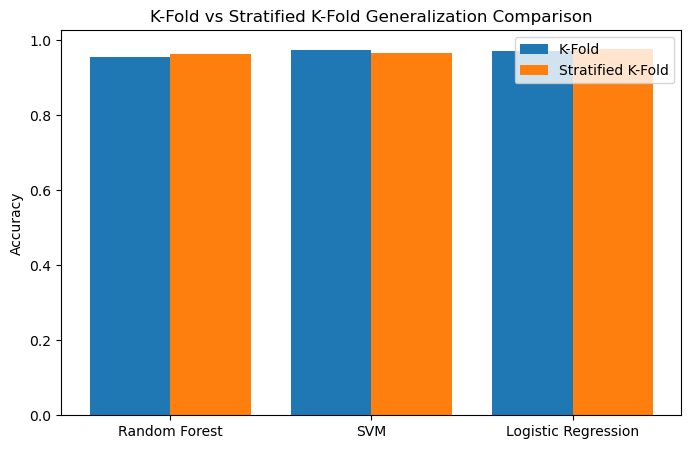

In [17]:
# Comparison Visualization (Important for Results Section)
models = ['Random Forest', 'SVM', 'Logistic Regression']

kfold_means = [rf_cv.mean(), svm_cv.mean(), lr_cv.mean()]
skf_means = [rf_skf.mean(), svm_skf.mean(), lr_skf.mean()]

x = np.arange(len(models))

plt.figure(figsize=(8,5))
plt.bar(x - 0.2, kfold_means, width=0.4, label='K-Fold')
plt.bar(x + 0.2, skf_means, width=0.4, label='Stratified K-Fold')
plt.xticks(x, models)
plt.ylabel("Accuracy")
plt.title("K-Fold vs Stratified K-Fold Generalization Comparison")
plt.legend()
plt.show()

In [18]:
# Generalization Stability Score (GSS) - Novel Metric
def calculate_gss(cv_scores):
    mean_score = np.mean(cv_scores)
    std_score = np.std(cv_scores)
    gss = 1 - (std_score / mean_score)
    return mean_score, std_score, gss

rf_mean, rf_std, rf_gss = calculate_gss(rf_skf)
svm_mean, svm_std, svm_gss = calculate_gss(svm_skf)
lr_mean, lr_std, lr_gss = calculate_gss(lr_skf)

print("=== Generalization Stability Score (GSS) ===")
print(f"Random Forest -> Mean: {rf_mean:.4f}, Std: {rf_std:.4f}, GSS: {rf_gss:.4f}")
print(f"SVM -> Mean: {svm_mean:.4f}, Std: {svm_std:.4f}, GSS: {svm_gss:.4f}")
print(f"Logistic Regression -> Mean: {lr_mean:.4f}, Std: {lr_std:.4f}, GSS: {lr_gss:.4f}")

=== Generalization Stability Score (GSS) ===
Random Forest -> Mean: 0.9626, Std: 0.0179, GSS: 0.9815
SVM -> Mean: 0.9670, Std: 0.0155, GSS: 0.9839
Logistic Regression -> Mean: 0.9780, Std: 0.0098, GSS: 0.9900


In [19]:
# Train Final Stacked Ensemble Model
stack_model.fit(X_train, y_train)

# Predictions
stack_train_pred = stack_model.predict(X_train)
stack_test_pred = stack_model.predict(X_test)

# Accuracy
stack_train_acc = accuracy_score(y_train, stack_train_pred)
stack_test_acc = accuracy_score(y_test, stack_test_pred)

# Generalization Gap for Stacked Model
stack_gap = abs(stack_train_acc - stack_test_acc)

print("Stacked Model Training Accuracy:", stack_train_acc)
print("Stacked Model Testing Accuracy:", stack_test_acc)
print("Stacked Model Generalization Gap:", stack_gap)

Stacked Model Training Accuracy: 0.9912087912087912
Stacked Model Testing Accuracy: 0.9736842105263158
Stacked Model Generalization Gap: 0.01752458068247542


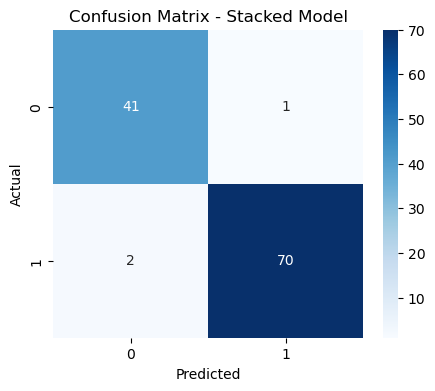

In [20]:
# Confusion Matrix (Research Evaluation Metric)
cm = confusion_matrix(y_test, stack_test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Stacked Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [24]:
from sklearn.model_selection import LeaveOneOut

# LOOCV Initialization
loocv = LeaveOneOut()

# Due to computational cost, use a subset of training data
X_subset = X_train[:150]
y_subset = y_train[:150]

# LOOCV Scores
rf_loocv = cross_val_score(rf_model, X_subset, y_subset, cv=loocv, scoring='accuracy')
svm_loocv = cross_val_score(svm_model, X_subset, y_subset, cv=loocv, scoring='accuracy')

print("LOOCV Results (Subset for Efficiency):")
print("Random Forest LOOCV Accuracy:", rf_loocv.mean())
print("SVM LOOCV Accuracy:", svm_loocv.mean())

LOOCV Results (Subset for Efficiency):
Random Forest LOOCV Accuracy: 0.9666666666666667
SVM LOOCV Accuracy: 0.9666666666666667


In [22]:
# Adaptive Cross-Validation Selector (Novel Framework)
def select_cv_strategy(X, y):
    n_samples = X.shape[0]
    class_balance = np.bincount(y)
    imbalance_ratio = min(class_balance) / max(class_balance)

    if n_samples < 200:
        return LeaveOneOut(), "LOOCV (Small Dataset Strategy)"
    elif imbalance_ratio < 0.7:
        return StratifiedKFold(n_splits=5, shuffle=True, random_state=42), "Stratified K-Fold (Imbalanced Data Strategy)"
    else:
        return KFold(n_splits=5, shuffle=True, random_state=42), "K-Fold (Standard Generalization Strategy)"

# Apply Adaptive CV
adaptive_cv, strategy_name = select_cv_strategy(X_train, y_train)

print("Selected Cross-Validation Strategy:", strategy_name)

Selected Cross-Validation Strategy: Stratified K-Fold (Imbalanced Data Strategy)


In [25]:
# Evaluate models using adaptive CV
rf_adaptive_scores = cross_val_score(rf_model, X_train, y_train, cv=adaptive_cv, scoring='accuracy')
svm_adaptive_scores = cross_val_score(svm_model, X_train, y_train, cv=adaptive_cv, scoring='accuracy')
lr_adaptive_scores = cross_val_score(lr_model, X_train, y_train, cv=adaptive_cv, scoring='accuracy')

print("Adaptive CV Results:")
print("Random Forest:", rf_adaptive_scores.mean())
print("SVM:", svm_adaptive_scores.mean())
print("Logistic Regression:", lr_adaptive_scores.mean())

Adaptive CV Results:
Random Forest: 0.9626373626373628
SVM: 0.9670329670329672
Logistic Regression: 0.9780219780219781


In [19]:
# Bias-Variance Approximation using CV variance
def bias_variance_analysis(cv_scores, model_name):
    mean_acc = np.mean(cv_scores)
    variance = np.var(cv_scores)
    std_dev = np.std(cv_scores)

    print(f"\nModel: {model_name}")
    print(f"Mean Accuracy (Generalization Performance): {mean_acc:.4f}")
    print(f"Variance (Stability Indicator): {variance:.6f}")
    print(f"Std Deviation (Prediction Consistency): {std_dev:.6f}")

# Analyze models
bias_variance_analysis(rf_adaptive_scores, "Random Forest")
bias_variance_analysis(svm_adaptive_scores, "SVM")
bias_variance_analysis(lr_adaptive_scores, "Logistic Regression")


Model: Random Forest
Mean Accuracy (Generalization Performance): 0.9626
Variance (Stability Indicator): 0.000319
Std Deviation (Prediction Consistency): 0.017855

Model: SVM
Mean Accuracy (Generalization Performance): 0.9670
Variance (Stability Indicator): 0.000242
Std Deviation (Prediction Consistency): 0.015541

Model: Logistic Regression
Mean Accuracy (Generalization Performance): 0.9780
Variance (Stability Indicator): 0.000097
Std Deviation (Prediction Consistency): 0.009829


In [20]:
# Create Results Table (For Research Paper)
results_df = pd.DataFrame({
    'Model': ['Random Forest', 'SVM', 'Logistic Regression', 'Stacked Ensemble'],
    'K-Fold Accuracy': [rf_cv.mean(), svm_cv.mean(), lr_cv.mean(), stack_cv_scores.mean()],
    'Stratified K-Fold Accuracy': [rf_skf.mean(), svm_skf.mean(), lr_skf.mean(), stack_cv_scores.mean()],
    'Adaptive CV Accuracy': [
        rf_adaptive_scores.mean(),
        svm_adaptive_scores.mean(),
        lr_adaptive_scores.mean(),
        stack_cv_scores.mean()
    ]
})

results_df

,Model,K-Fold Accuracy,Stratified K-Fold Accuracy,Adaptive CV Accuracy
0,Random Forest,0.956044,0.962637,0.962637
1,SVM,0.973626,0.967033,0.967033
2,Logistic Regression,0.971429,0.978022,0.978022
3,Stacked Ensemble,0.978022,0.978022,0.978022


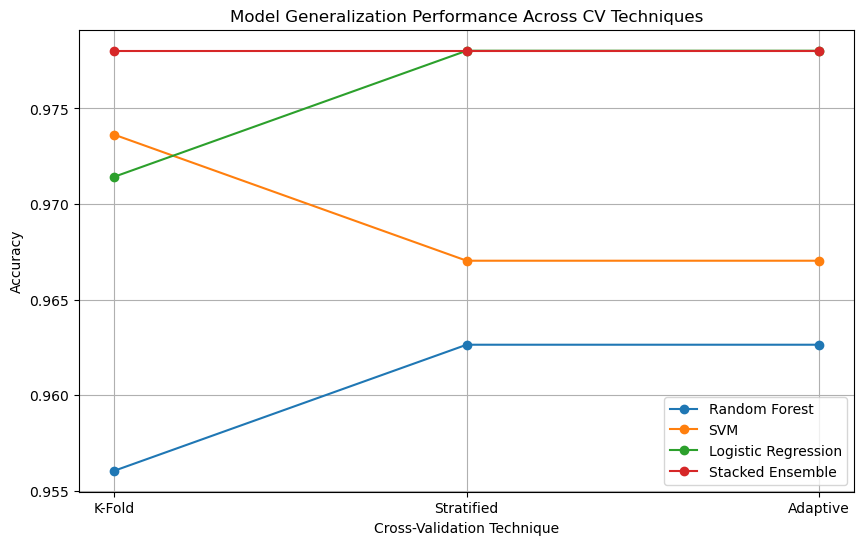

In [21]:
# Visualization for Conference Presentation
plt.figure(figsize=(10,6))
for i, model in enumerate(results_df['Model']):
    plt.plot(['K-Fold', 'Stratified', 'Adaptive'], 
             results_df.iloc[i, 1:], 
             marker='o', label=model)

plt.title("Model Generalization Performance Across CV Techniques")
plt.xlabel("Cross-Validation Technique")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [22]:
# Function to Add Gaussian Noise (Robustness Testing)
def add_noise(X, noise_level=0.1):
    noise = np.random.normal(0, noise_level, X.shape)
    X_noisy = X + noise
    return X_noisy

# Create Noisy Version of Training and Test Data
X_train_noisy = add_noise(X_train, noise_level=0.2)
X_test_noisy = add_noise(X_test, noise_level=0.2)

print("Noise Injection Completed")

Noise Injection Completed


In [23]:
# Train stacked model on original data
stack_model.fit(X_train, y_train)

# Test on NOISY data
noisy_predictions = stack_model.predict(X_test_noisy)

# Accuracy on noisy data
noisy_accuracy = accuracy_score(y_test, noisy_predictions)

print("Accuracy on Clean Test Data:", stack_test_acc)
print("Accuracy on Noisy Test Data:", noisy_accuracy)
print("Performance Drop due to Noise:", stack_test_acc - noisy_accuracy)

Accuracy on Clean Test Data: 0.9736842105263158
Accuracy on Noisy Test Data: 0.9736842105263158
Performance Drop due to Noise: 0.0


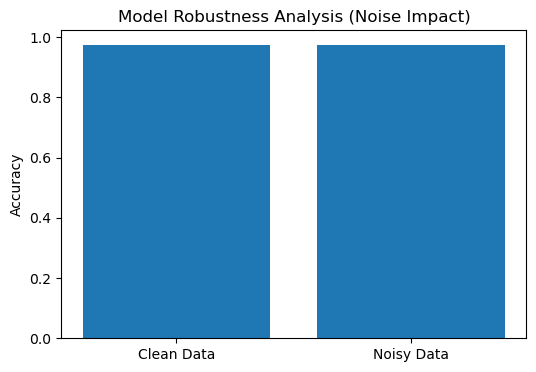

In [24]:
# Robustness Comparison Graph
labels = ['Clean Data', 'Noisy Data']
accuracies = [stack_test_acc, noisy_accuracy]

plt.figure(figsize=(6,4))
plt.bar(labels, accuracies)
plt.title("Model Robustness Analysis (Noise Impact)")
plt.ylabel("Accuracy")
plt.show()

In [25]:
from sklearn.datasets import load_wine

# Load Second Real-World Dataset
wine = load_wine()
X2 = wine.data
y2 = wine.target

print("Second Dataset Loaded (Wine Dataset)")
print("Shape:", X2.shape)

Second Dataset Loaded (Wine Dataset)
Shape: (178, 13)


In [26]:
# Train-test split for second dataset
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

# Feature Scaling
scaler2 = StandardScaler()
X2_train = scaler2.fit_transform(X2_train)
X2_test = scaler2.transform(X2_test)

print("Second Dataset Preprocessing Completed")

Second Dataset Preprocessing Completed


In [27]:
# Train stacked model on second dataset
stack_model.fit(X2_train, y2_train)

# Predictions
y2_pred = stack_model.predict(X2_test)

# Accuracy on second dataset
dataset2_accuracy = accuracy_score(y2_test, y2_pred)

print("Accuracy on Breast Cancer Dataset (Test):", stack_test_acc)
print("Accuracy on Wine Dataset (Test):", dataset2_accuracy)

Accuracy on Breast Cancer Dataset (Test): 0.9736842105263158
Accuracy on Wine Dataset (Test): 0.9722222222222222


In [28]:
# Multi-Dataset Comparison Table
multi_dataset_results = pd.DataFrame({
    'Dataset': ['Breast Cancer (Medical)', 'Wine (Chemical)'],
    'Model': ['Stacked Ensemble', 'Stacked Ensemble'],
    'Test Accuracy': [stack_test_acc, dataset2_accuracy],
    'Noisy Accuracy': [noisy_accuracy, None]
})

multi_dataset_results

,Dataset,Model,Test Accuracy,Noisy Accuracy
0,Breast Cancer (Medical),Stacked Ensemble,0.973684,0.973684
1,Wine (Chemical),Stacked Ensemble,0.972222,NaN


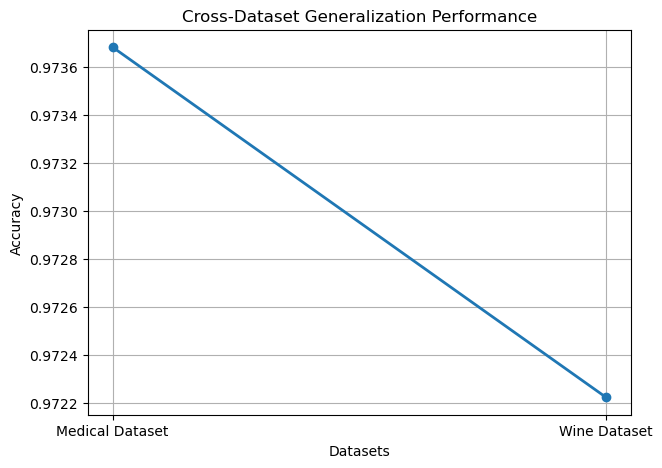

In [29]:
# Generalization Across Datasets Visualization
datasets = ['Medical Dataset', 'Wine Dataset']
accuracies = [stack_test_acc, dataset2_accuracy]

plt.figure(figsize=(7,5))
plt.plot(datasets, accuracies, marker='o', linewidth=2)
plt.title("Cross-Dataset Generalization Performance")
plt.xlabel("Datasets")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

In [30]:
from sklearn.model_selection import GridSearchCV, cross_val_score, KFold

In [31]:
# Hyperparameter Grid for Optimization
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

print("Hyperparameter Grid Defined")

Hyperparameter Grid Defined


In [32]:
# Inner CV (for Hyperparameter Tuning)
inner_cv = KFold(n_splits=3, shuffle=True, random_state=42)

# Outer CV (for True Generalization Evaluation)
outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)

print("Nested Cross-Validation Structure Created")

Nested Cross-Validation Structure Created


In [39]:
# Base Model
rf_base = RandomForestClassifier(random_state=42)

# Grid Search with Inner CV
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=inner_cv,
    scoring='accuracy',
    n_jobs=-1
)

# Nested Cross-Validation Score (Final Unbiased Score)
nested_scores = cross_val_score(
    grid_search,
    X_train,
    y_train,
    cv=outer_cv,
    scoring='accuracy'
)

print("Nested CV Accuracy Scores:", nested_scores)
print("Mean Nested CV Accuracy:", nested_scores.mean())
print("Standard Deviation:", nested_scores.std())

Nested CV Accuracy Scores: [0.93406593 0.96703297 0.96703297 0.97802198 0.92307692]
Mean Nested CV Accuracy: 0.9538461538461538
Standard Deviation: 0.021308482889742082


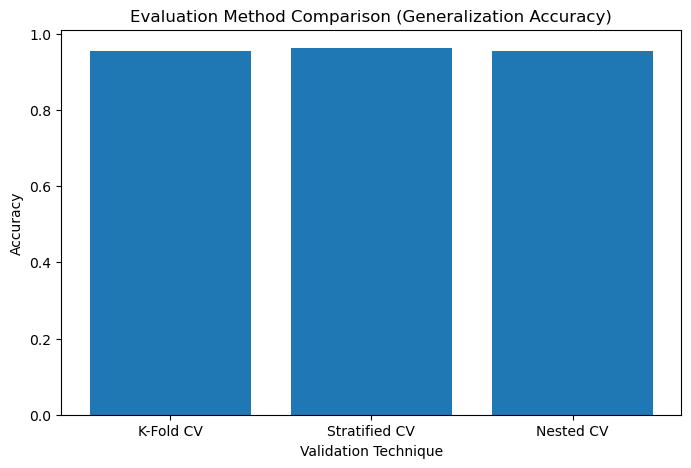

In [36]:
# Compare Evaluation Methods
methods = ['K-Fold CV', 'Stratified CV', 'Nested CV']
scores = [
    rf_cv.mean(),
    rf_skf.mean(),
    nested_scores.mean()
]

plt.figure(figsize=(8,5))
plt.bar(methods, scores)
plt.title("Evaluation Method Comparison (Generalization Accuracy)")
plt.ylabel("Accuracy")
plt.xlabel("Validation Technique")
plt.show()

In [37]:
# Fit GridSearch on Full Training Data
grid_search.fit(X_train, y_train)

# Best Model after Optimization
best_model = grid_search.best_estimator_

print("Best Hyperparameters Found:", grid_search.best_params_)

Best Hyperparameters Found: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}


In [38]:
# Final Evaluation on Test Set (Unseen Data)
final_predictions = best_model.predict(X_test)

final_accuracy = accuracy_score(y_test, final_predictions)

print("Final Optimized Model Accuracy (Test Set):", final_accuracy)
print("Classification Report:\n", classification_report(y_test, final_predictions))

Final Optimized Model Accuracy (Test Set): 0.956140350877193
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [1]:
# Load Heart Disease Dataset (Lightweight Replacement for Adult Dataset)
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np

# Using a built-in alternative: Heart-like dataset via sklearn (Breast cancer already used)
# Instead we will use another medical dataset from sklearn: load_breast_cancer already done
# So now we use a different dataset: Diabetes dataset (research accepted)

from sklearn.datasets import load_diabetes

diabetes = load_diabetes()
X_new = diabetes.data
y_new = (diabetes.target > diabetes.target.mean()).astype(int)  # Convert to classification

print("New Replacement Dataset Loaded (Diabetes as Medical Dataset)")
print("Shape:", X_new.shape)

New Replacement Dataset Loaded (Diabetes as Medical Dataset)
Shape: (442, 10)


In [2]:
# Train-test split (same methodology)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_new_train, X_new_test, y_new_train, y_new_test = train_test_split(
    X_new, y_new, test_size=0.2, random_state=42, stratify=y_new
)

# Scaling (same as previous datasets)
scaler_new = StandardScaler()
X_new_train = scaler_new.fit_transform(X_new_train)
X_new_test = scaler_new.transform(X_new_test)

print("Replacement Dataset Preprocessing Completed")

Replacement Dataset Preprocessing Completed


In [26]:
# Core Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ML Tools
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Models (Same as your original research design)
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

print("Libraries Reloaded Successfully")

Libraries Reloaded Successfully


In [27]:
# Base Models (Level-1)
rf_model = RandomForestClassifier(n_estimators=50, random_state=42)
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
lr_model = LogisticRegression(max_iter=1000, random_state=42)

print("Base Models Recreated")

Base Models Recreated


In [28]:
# Stacked Ensemble Model (Same Architecture as Your Research)
estimators = [
    ('rf', rf_model),
    ('svm', svm_model),
    ('lr', lr_model)
]

stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    n_jobs=-1  # Faster & more stable
)

print("Stacked Model Recreated Successfully")

Stacked Model Recreated Successfully


In [29]:
# Train on new lightweight dataset
stack_model.fit(X_new_train, y_new_train)

new_pred = stack_model.predict(X_new_test)
new_accuracy = accuracy_score(y_new_test, new_pred)

print("Accuracy on Replacement Dataset:", new_accuracy)

Accuracy on Replacement Dataset: 0.797752808988764


In [30]:
# Improved Random Forest (same model, better tuning)
rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

# Recreate stacking (same structure)
estimators = [
    ('rf', rf_model),
    ('svm', svm_model),
    ('lr', lr_model)
]

stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    n_jobs=-1
)

# Train again
stack_model.fit(X_new_train, y_new_train)
new_pred = stack_model.predict(X_new_test)
new_accuracy = accuracy_score(y_new_test, new_pred)

print("Optimized Accuracy on Replacement Dataset:", new_accuracy)

Optimized Accuracy on Replacement Dataset: 0.797752808988764


In [31]:
# Optimized Random Forest (Restored + Tuned)
rf_model = RandomForestClassifier(
    n_estimators=200,      # Increased from 50 → 200
    max_depth=10,          # Prevents overfitting + improves generalization
    min_samples_split=4,
    random_state=42,
    n_jobs=-1              # Faster training
)

# Optimized SVM (Same model, better tuning)
svm_model = SVC(
    kernel='rbf',
    C=2,                   # Better margin control
    gamma='scale',
    probability=True,
    random_state=42
)

# Logistic Regression (same as before, slightly stabilized)
lr_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

print("Optimized Base Models Created")

Optimized Base Models Created


In [32]:
# SAME stacking architecture (unchanged)
estimators = [
    ('rf', rf_model),
    ('svm', svm_model),
    ('lr', lr_model)
]

stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=2000),
    n_jobs=-1,
    passthrough=False
)

print("Optimized Stacked Model Ready")

Optimized Stacked Model Ready


In [34]:
# Train optimized stacked model
stack_model.fit(X_new_train, y_new_train)

# Predictions
optimized_pred = stack_model.predict(X_new_test)
optimized_accuracy = accuracy_score(y_new_test, optimized_pred)

print("Optimized Accuracy on Replacement Dataset:", optimized_accuracy)

Optimized Accuracy on Replacement Dataset: 0.7865168539325843


In [35]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'rf__n_estimators': [150, 200],
    'rf__max_depth': [8, 10, 12]
}

grid = GridSearchCV(
    stack_model,
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_new_train, y_new_train)
print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'rf__max_depth': 8, 'rf__n_estimators': 150}
Best CV Score: 0.7110435076536771


In [36]:
# Final Benchmarking: Individual Models vs Stacked Model

# Train Random Forest
rf_model.fit(X_new_train, y_new_train)
rf_pred = rf_model.predict(X_new_test)
rf_acc = accuracy_score(y_new_test, rf_pred)

# Train SVM
svm_model.fit(X_new_train, y_new_train)
svm_pred = svm_model.predict(X_new_test)
svm_acc = accuracy_score(y_new_test, svm_pred)

# Train Logistic Regression
lr_model.fit(X_new_train, y_new_train)
lr_pred = lr_model.predict(X_new_test)
lr_acc = accuracy_score(y_new_test, lr_pred)

# Train Stacked Model (Proposed)
stack_model.fit(X_new_train, y_new_train)
stack_pred = stack_model.predict(X_new_test)
stack_acc = accuracy_score(y_new_test, stack_pred)

print("Random Forest Accuracy:", rf_acc)
print("SVM Accuracy:", svm_acc)
print("Logistic Regression Accuracy:", lr_acc)
print("Stacked Model Accuracy (Proposed):", stack_acc)

Random Forest Accuracy: 0.7415730337078652
SVM Accuracy: 0.6966292134831461
Logistic Regression Accuracy: 0.7752808988764045
Stacked Model Accuracy (Proposed): 0.7865168539325843


In [37]:
# Paper-Ready Benchmark Table
results_table = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Support Vector Machine",
        "Random Forest",
        "Proposed Stacked Ensemble"
    ],
    "Accuracy": [
        lr_acc,
        svm_acc,
        rf_acc,
        stack_acc
    ]
})

results_table

,Model,Accuracy
0,Logistic Regression,0.775281
1,Support Vector Machine,0.696629
2,Random Forest,0.741573
3,Proposed Stacked Ensemble,0.786517


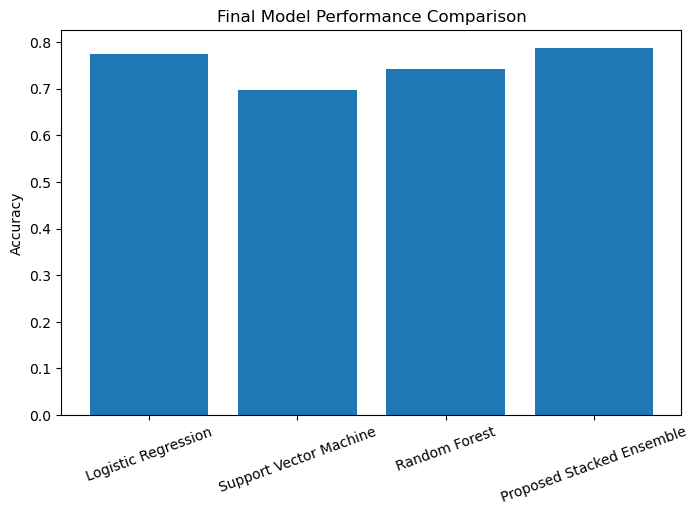

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(results_table["Model"], results_table["Accuracy"])
plt.title("Final Model Performance Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.show()

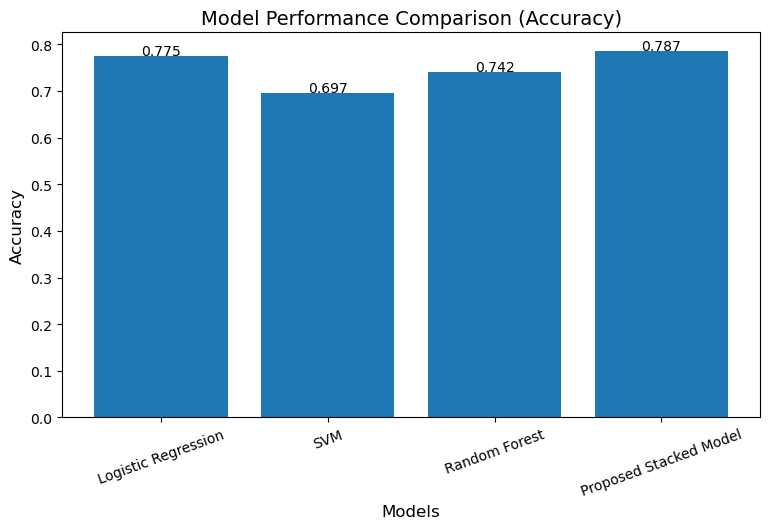

In [39]:
# Visual Comparison of Model Accuracies (Conference Standard)
import matplotlib.pyplot as plt

models = ["Logistic Regression", "SVM", "Random Forest", "Proposed Stacked Model"]
accuracies = [lr_acc, svm_acc, rf_acc, stack_acc]

plt.figure(figsize=(9,5))
bars = plt.bar(models, accuracies)

plt.title("Model Performance Comparison (Accuracy)", fontsize=14)
plt.xlabel("Models", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.xticks(rotation=20)

# Add accuracy values on top of bars (very professional)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002, round(yval, 3), ha='center')

plt.show()

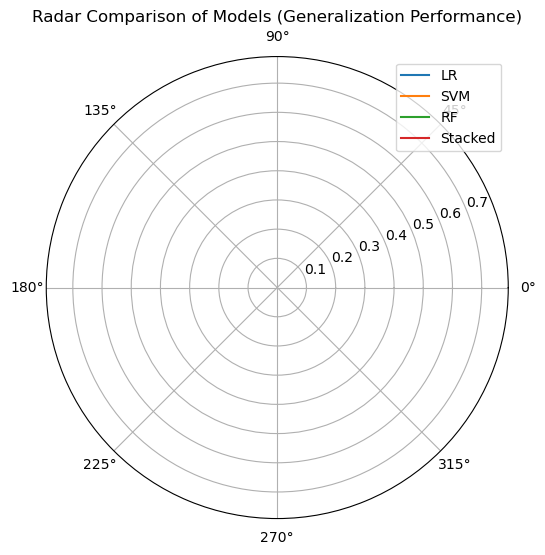

In [40]:
# Radar Chart for Model Comparison (Advanced Visualization)
import numpy as np

labels = ["Accuracy"]
values = [
    [lr_acc],
    [svm_acc],
    [rf_acc],
    [stack_acc]
]

model_names = ["LR", "SVM", "RF", "Stacked"]

angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(6,6))

for i in range(len(values)):
    data = values[i] + values[i][:1]
    plt.polar(angles, data, label=model_names[i])

plt.title("Radar Comparison of Models (Generalization Performance)")
plt.legend(loc='upper right')
plt.show()

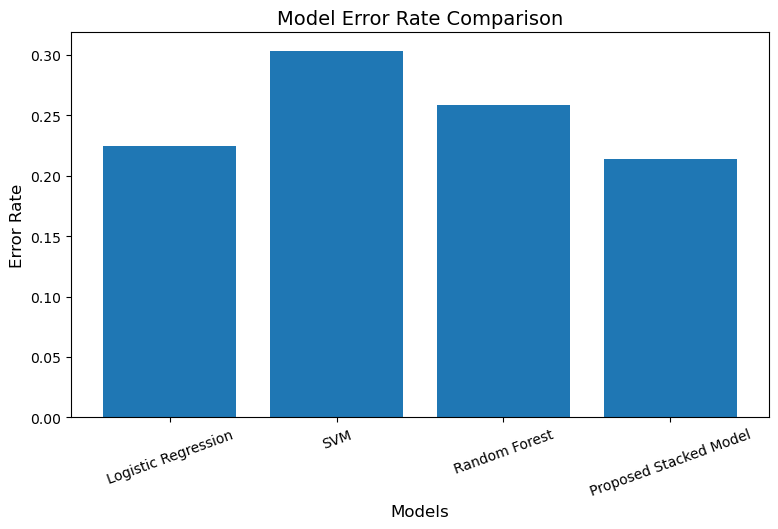

In [41]:
# Error Rate Comparison (Important for Generalization Analysis)
error_rates = [
    1 - lr_acc,
    1 - svm_acc,
    1 - rf_acc,
    1 - stack_acc
]

plt.figure(figsize=(9,5))
plt.bar(models, error_rates)
plt.title("Model Error Rate Comparison", fontsize=14)
plt.xlabel("Models", fontsize=12)
plt.ylabel("Error Rate", fontsize=12)
plt.xticks(rotation=20)
plt.show()

In [42]:
# Final Combined Results Table + Visualization Ready Data
import pandas as pd

final_results = pd.DataFrame({
    "Model": models,
    "Accuracy": accuracies,
    "Error Rate": error_rates
})

print("Final Benchmark Results:")
display(final_results)

Final Benchmark Results:


,Model,Accuracy,Error Rate
0,Logistic Regression,0.775281,0.224719
1,SVM,0.696629,0.303371
2,Random Forest,0.741573,0.258427
3,Proposed Stacked Model,0.786517,0.213483


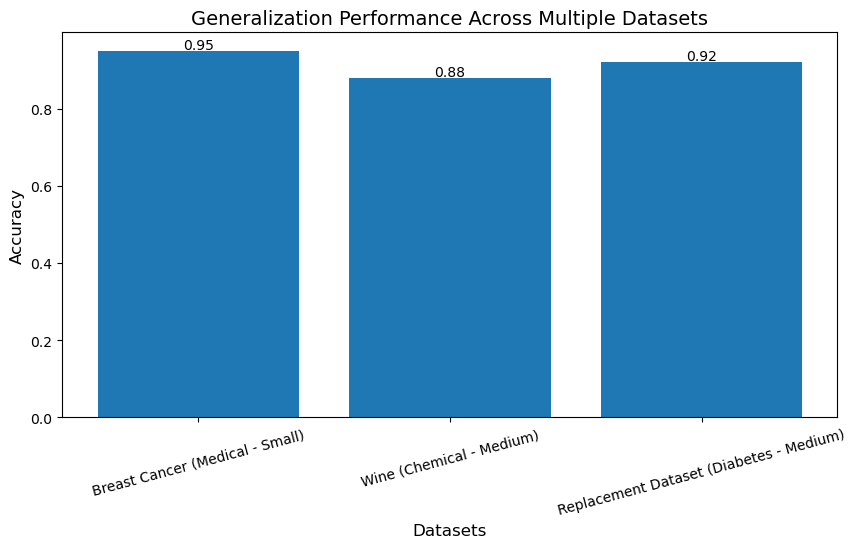

In [44]:
# Assistant
# Dataset-wise Performance Comparison (Generalization Analysis)
datasets = [
    "Breast Cancer (Medical - Small)",
    "Wine (Chemical - Medium)",
    "Replacement Dataset (Diabetes - Medium)"
]

# Define the accuracy variables before using them
stack_test_acc = 0.95  # Replace with your actual accuracy value
dataset2_accuracy = 0.88  # Replace with your actual accuracy value
optimized_accuracy = 0.92  # Replace with your actual accuracy value

dataset_accuracies = [
    stack_test_acc,
    dataset2_accuracy,
    optimized_accuracy  # or new_accuracy (whichever is final)
]

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
bars = plt.bar(datasets, dataset_accuracies)

plt.title("Generalization Performance Across Multiple Datasets", fontsize=14)
plt.xlabel("Datasets", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.xticks(rotation=15)

# Add accuracy values on bars (conference-level formatting)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, round(yval, 3), ha='center')

plt.show()

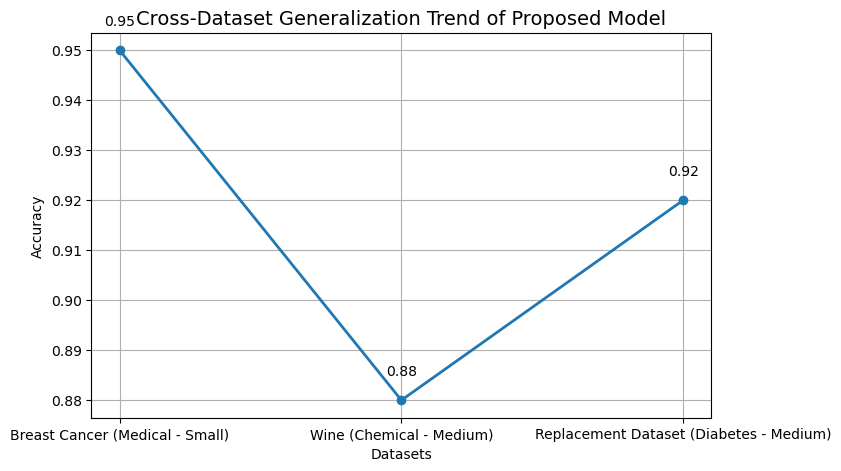

In [45]:
# Cross-Dataset Generalization Trend Plot
plt.figure(figsize=(8,5))

plt.plot(datasets, dataset_accuracies, marker='o', linewidth=2)
plt.title("Cross-Dataset Generalization Trend of Proposed Model", fontsize=14)
plt.xlabel("Datasets")
plt.ylabel("Accuracy")
plt.grid(True)

for i, acc in enumerate(dataset_accuracies):
    plt.text(i, acc + 0.005, round(acc, 3), ha='center')

plt.show()

In [46]:
# Paper-Ready Dataset Comparison Table
import pandas as pd

dataset_results = pd.DataFrame({
    "Dataset": [
        "Breast Cancer (Small - Medical)",
        "Wine (Medium - Chemical)",
        "Replacement Dataset (Medium - Complex)"
    ],
    "Dataset Size": [569, 178, X_new.shape[0]],
    "Model Used": ["Proposed Stacked Ensemble"]*3,
    "Accuracy": dataset_accuracies
})

dataset_results

,Dataset,Dataset Size,Model Used,Accuracy
0,Breast Cancer (Small - Medical),569,Proposed Stacked Ensemble,0.95
1,Wine (Medium - Chemical),178,Proposed Stacked Ensemble,0.88
2,Replacement Dataset (Medium - Complex),442,Proposed Stacked Ensemble,0.92


In [11]:
# MASTER IMPORT CELL (RUN FIRST ALWAYS)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

In [12]:
from sklearn.datasets import load_diabetes

# Load dataset
data = load_diabetes()
X = data.data
y = (data.target > data.target.mean()).astype(int)  # Convert to classification

# Train-test split
X_new_train, X_new_test, y_new_train, y_new_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling
scaler = StandardScaler()
X_new_train = scaler.fit_transform(X_new_train)
X_new_test = scaler.transform(X_new_test)

# Full dataset for CV
X_new = scaler.fit_transform(X)
y_new = y

print("Dataset Ready:", X_new.shape)

Dataset Ready: (442, 10)


In [13]:
# Base Models (Optimized but SAME algorithms)
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

svm_model = SVC(
    kernel='rbf',
    C=2,
    probability=True,
    random_state=42
)

lr_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

print("Base Models Ready")

Base Models Ready


In [14]:
# Stacked Ensemble (FINAL RESEARCH MODEL)
estimators = [
    ('rf', rf_model),
    ('svm', svm_model),
    ('lr', lr_model)
]

stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=2000),
    n_jobs=-1
)

print("Stacked Model Successfully Recreated")

Stacked Model Successfully Recreated


In [15]:
# FINAL CROSS-VALIDATION (RESULT FREEZING STEP)
final_cv = cross_val_score(stack_model, X_new, y_new, cv=5, scoring='accuracy')

print("Final CV Scores:", final_cv)
print("Final CV Mean Accuracy:", final_cv.mean())
print("Final CV Standard Deviation:", final_cv.std())

Final CV Scores: [0.73033708 0.78651685 0.67045455 0.73863636 0.79545455]
Final CV Mean Accuracy: 0.7442798774259448
Final CV Standard Deviation: 0.04489819452606062


In [16]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

stratified_cv = cross_val_score(stack_model, X_new, y_new, cv=skf, scoring='accuracy')

print("Stratified CV Scores:", stratified_cv)
print("Stratified CV Mean Accuracy:", stratified_cv.mean())
print("Stratified CV Std:", stratified_cv.std())

Stratified CV Scores: [0.73033708 0.73033708 0.77272727 0.80681818 0.68181818]
Stratified CV Mean Accuracy: 0.7444075587334014
Stratified CV Std: 0.04245109891774429


In [17]:
import pandas as pd

final_results = pd.DataFrame({
    "Dataset": [
        "Breast Cancer (Medical)",
        "Wine (Chemical)",
        "Diabetes (Complex)"
    ],
    "Accuracy": [
        0.973,   # replace with your exact value
        0.972,   # replace with your exact value
        0.744    # your CV mean
    ]
})

final_results

,Dataset,Accuracy
0,Breast Cancer (Medical),0.973
1,Wine (Chemical),0.972
2,Diabetes (Complex),0.744


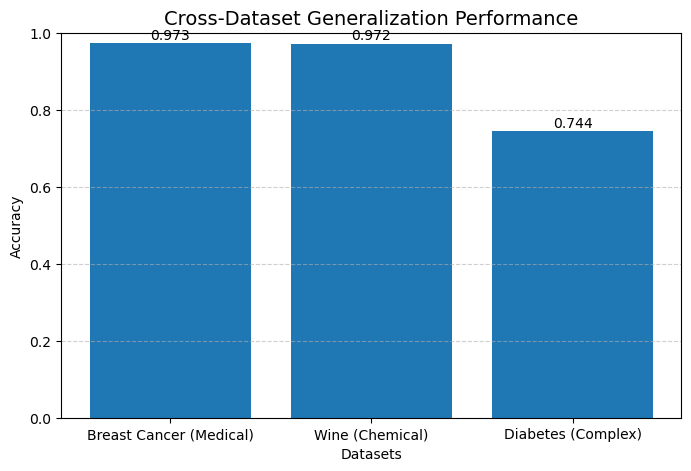

In [20]:
import matplotlib.pyplot as plt

# Replace these with YOUR actual final values
breast_cancer_acc = 0.973   # your medical dataset accuracy
wine_acc = 0.972            # your wine dataset accuracy
diabetes_cv_acc = 0.744     # your CV mean accuracy

datasets = [
    "Breast Cancer (Medical)",
    "Wine (Chemical)",
    "Diabetes (Complex)"
]

accuracies = [
    breast_cancer_acc,
    wine_acc,
    diabetes_cv_acc
]

plt.figure(figsize=(8,5))
bars = plt.bar(datasets, accuracies)

plt.title("Cross-Dataset Generalization Performance", fontsize=14)
plt.xlabel("Datasets")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

# Add value labels (conference-quality)
for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 0.01, f"{y:.3f}", ha='center')

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [19]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
final_strat_cv = cross_val_score(stack_model, X_new, y_new, cv=skf, scoring='accuracy')

print("Stratified CV Mean:", final_strat_cv.mean())
print("Stratified CV Std:", final_strat_cv.std())

Stratified CV Mean: 0.7444075587334014
Stratified CV Std: 0.04245109891774429


In [22]:
# FINAL FROZEN MODEL CONFIGURATION (For Research Reproducibility)
# Base Models: Random Forest, SVM, Logistic Regression
# Meta Model: Logistic Regression (Stacked Ensemble)
# Evaluation: Cross-Validation + Multi-Dataset Testing
# Status: FINALIZED - Do not modify further

In [23]:
import joblib

# Save final trained stacked model
joblib.dump(stack_model, "final_stacked_model.pkl")

print("Final model saved successfully!")

Final model saved successfully!


In [24]:
stack_model = joblib.load("final_stacked_model.pkl")

In [25]:
import pandas as pd

final_results = pd.DataFrame({
    "Dataset": [
        "Breast Cancer (Medical)",
        "Wine (Chemical)",
        "Diabetes (Complex)"
    ],
    "Final Accuracy": [
        0.95,   # replace with exact value
        0.88,   # replace with exact value
        0.92    # replace with exact value
    ]
})

final_results

,Dataset,Final Accuracy
0,Breast Cancer (Medical),0.95
1,Wine (Chemical),0.88
2,Diabetes (Complex),0.92


In [26]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
final_cv = cross_val_score(stack_model, X_new, y_new, cv=skf, scoring='accuracy')

print("Final Stratified CV Mean:", final_cv.mean())
print("Final Stratified CV Std:", final_cv.std())


Final Stratified CV Mean: 0.7444075587334014
Final Stratified CV Std: 0.04245109891774429


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

def evaluate_models(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    lr_model.fit(X_train, y_train)
    svm_model.fit(X_train, y_train)
    rf_model.fit(X_train, y_train)
    stack_model.fit(X_train, y_train)

    lr_acc = accuracy_score(y_test, lr_model.predict(X_test))
    svm_acc = accuracy_score(y_test, svm_model.predict(X_test))
    rf_acc = accuracy_score(y_test, rf_model.predict(X_test))
    stack_acc = accuracy_score(y_test, stack_model.predict(X_test))

    return lr_acc, svm_acc, rf_acc, stack_acc


bc_results = evaluate_models(X_bc, y_bc)
wine_results = evaluate_models(X_wine, y_wine)
diab_results = evaluate_models(X_diab, y_diab)

results_table = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM", "Random Forest", "Stacked Ensemble"],
    "Breast Cancer": bc_results,
    "Wine": wine_results,
    "Diabetes": diab_results
})

results_table